# Phase 2 — RUL label construction (FD001)

Objective: construct the training target correctly. This is the single most impactful
modeling decision — get it wrong and the model trains on false signal for the first 60–70%
of each engine's life.

See `doc/plan.md` Phase 2 for the full spec. Deliverable: `train_df` augmented with a capped
`rul` column, a visualization of the cap effect, and a written justification of the 125-cycle
cap threshold.

## 0. Load data

Same parsing as Phase 0/1 — reload `train_df`, `test_df`, `rul_true` fresh in this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data")

# Fixed, colorblind-safe categorical palette (8 slots, ordered — do not reorder or cycle).
# Source: dataviz skill reference palette; validated on the adjacent-pairlist for line charts.
CATEGORICAL_PALETTE = [
    "#2a78d6",  # 1 blue
    "#eb6834",  # 2 orange
    "#1baf7a",  # 3 aqua
    "#eda100",  # 4 yellow
    "#e87ba4",  # 5 magenta
    "#008300",  # 6 green
    "#4a3aa7",  # 7 violet
    "#e34948",  # 8 red
]

SURFACE = "#fcfcfb"
GRIDLINE = "#e1e0d9"
AXIS = "#c3c2b7"
MUTED = "#898781"
INK = "#0b0b0b"

plt.rcParams["figure.facecolor"] = SURFACE
plt.rcParams["axes.facecolor"] = SURFACE
plt.rcParams["font.size"] = 10

In [2]:
COLUMNS = (
    ["engine_id", "cycle", "op_1", "op_2", "op_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)


def load_fd001(filename: str) -> pd.DataFrame:
    df = pd.read_csv(
        DATA_DIR / filename,
        sep=r"\s+",
        header=None,
        names=COLUMNS,
    )
    df["engine_id"] = df["engine_id"].astype(int)
    df["cycle"] = df["cycle"].astype(int)
    return df


train_df = load_fd001("train_FD001.txt")
test_df = load_fd001("test_FD001.txt")

rul_true = pd.read_csv(
    DATA_DIR / "RUL_FD001.txt",
    sep=r"\s+",
    header=None,
    names=["rul"],
)["rul"]
rul_true.index = rul_true.index + 1
rul_true.index.name = "engine_id"

SENSOR_COLS = [f"sensor_{i}" for i in range(1, 22)]

train_df.shape, test_df.shape, rul_true.shape

((20631, 26), (13096, 26), (100,))

## 1. Linear RUL label

For each engine, remaining useful life at a given cycle is simply how many cycles are left
before that engine's last observed (failure) cycle: `max_cycle - cycle`, computed independently
per `engine_id` so no engine's countdown leaks into another's. This is the raw linear label —
uncapped, counting straight down to 0 at the engine's final row.

In [3]:
max_cycle = train_df.groupby("engine_id")["cycle"].transform("max")
print(max_cycle)
print(max_cycle.min())

0        192
1        192
2        192
3        192
4        192
        ... 
20626    200
20627    200
20628    200
20629    200
20630    200
Name: cycle, Length: 20631, dtype: int64
128


In [4]:
max_cycle = train_df.groupby("engine_id")["cycle"].transform("max")
train_df["rul"] = max_cycle - train_df["cycle"]

train_df[["engine_id", "cycle", "rul"]].head()

,engine_id,cycle,rul
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


In [5]:
# Sanity check: last row of every engine should have rul == 0, first row should have
# rul == max_cycle - 1 (cycles are 1-indexed).
last_rows = train_df.groupby("engine_id").tail(1)
first_rows = train_df.groupby("engine_id").head(1)
expected_start_rul = max_cycle.loc[first_rows.index] - 1

print("all engines end at rul == 0:", bool((last_rows["rul"] == 0).all()))
print("all engines start at rul == max_cycle - 1:", bool((first_rows["rul"] == expected_start_rul).all()))
train_df["rul"].describe()

all engines end at rul == 0: True
all engines start at rul == max_cycle - 1: True


count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: rul, dtype: float64

## 2. Apply the piecewise-linear cap

Clip `rul` at 125 cycles. In the healthy phase (more than ~125 cycles from failure), raw linear
RUL asks the model to distinguish e.g. RUL = 300 from RUL = 350 using sensor readings that are
statistically identical in that phase — the model can't learn that, it just learns noise. Capping
converts all healthy-phase labels to a constant 125, so the model is only asked to resolve RUL
where the sensors actually carry a resolvable signal. The cap is applied on top of the raw `rul`
column just computed in Section 1, so `train_df['rul']` is now the target used for training
(`rul_raw` is kept separately below for the Section 3/4 visual comparisons).

In [6]:
RUL_CAP = 125

train_df["rul_raw"] = train_df["rul"]
train_df["rul"] = train_df["rul"].clip(upper=RUL_CAP)

n_capped = int((train_df["rul_raw"] > RUL_CAP).sum())
print(f"rows capped: {n_capped} / {len(train_df)} ({n_capped / len(train_df):.1%})")
train_df[["engine_id", "cycle", "rul_raw", "rul"]].describe()

rows capped: 8031 / 20631 (38.9%)


,engine_id,cycle,rul_raw,rul
count,20631.000000,20631.000000,20631.000000,20631.000000
mean,51.506568,108.807862,107.807862,86.829286
std,29.227633,68.880990,68.880990,41.673699
min,1.000000,1.000000,0.000000,0.000000
25%,26.000000,52.000000,51.000000,51.000000
50%,52.000000,104.000000,103.000000,103.000000
75%,77.000000,156.000000,155.000000,125.000000
max,100.000000,362.000000,361.000000,125.000000


## 3. Visualize the cap effect

Plot raw RUL vs. capped RUL over cycle for 4 engines: the shortest-lived training engine, the
longest-lived, and 2 chosen at random (fixed seed, reproducible). The raw label is a straight
diagonal descent to 0 for every engine regardless of lifetime. The capped label should be flat at
125 for the healthy phase, then rejoin the raw diagonal exactly at `rul_raw == 125` and descend
with it to 0. Since every FD001 training engine lives at least ~128 cycles (just over the 125
cap), even the shortest-lived engine should show at least a small flat nub rather than looking
completely unchanged.

In [7]:
engine_max_cycle = train_df.groupby("engine_id")["cycle"].max()
shortest_engine = int(engine_max_cycle.idxmin())
longest_engine = int(engine_max_cycle.idxmax())

rng = np.random.default_rng(42)
remaining = engine_max_cycle.index.difference([shortest_engine, longest_engine])
random_engines = sorted(int(e) for e in rng.choice(remaining, size=2, replace=False))

CAP_DEMO_ENGINES = [shortest_engine] + random_engines + [longest_engine]
CAP_DEMO_LABELS = ["shortest-lived"] + ["random"] * 2 + ["longest-lived"]

for engine_id, label in zip(CAP_DEMO_ENGINES, CAP_DEMO_LABELS):
    print(f"engine {engine_id:>3} ({label}): {engine_max_cycle[engine_id]} cycles")

engine  39 (shortest-lived): 128 cycles
engine   9 (random): 201 cycles
engine  78 (random): 231 cycles
engine  69 (longest-lived): 362 cycles


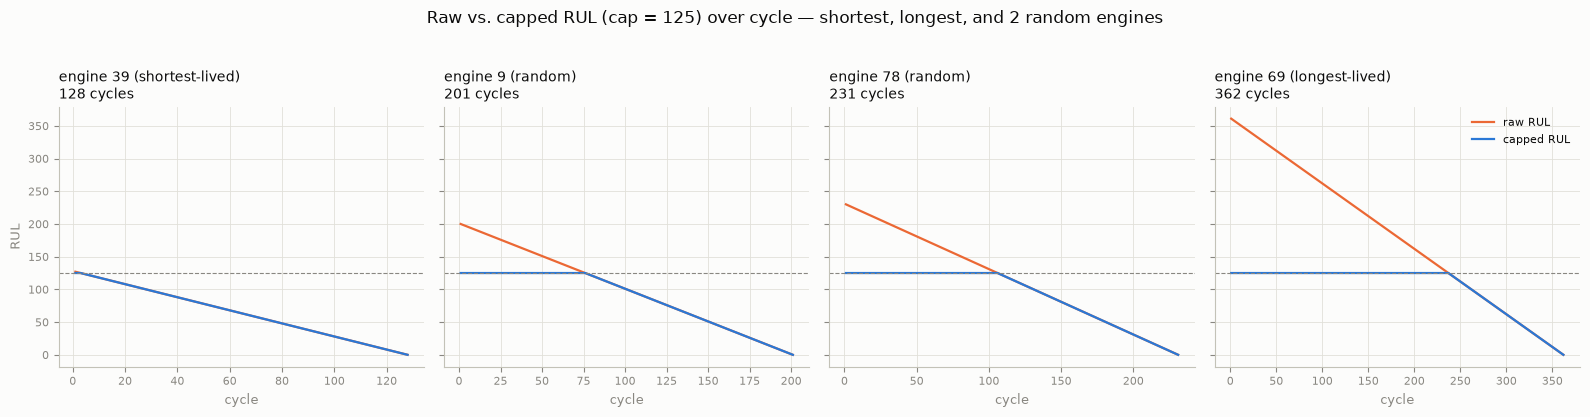

In [8]:
RAW_COLOR = CATEGORICAL_PALETTE[1]  # orange
CAPPED_COLOR = CATEGORICAL_PALETTE[0]  # blue

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, engine_id, label in zip(axes, CAP_DEMO_ENGINES, CAP_DEMO_LABELS):
    eng = train_df[train_df["engine_id"] == engine_id]
    ax.plot(eng["cycle"], eng["rul_raw"], color=RAW_COLOR, linewidth=1.6, label="raw RUL")
    ax.plot(eng["cycle"], eng["rul"], color=CAPPED_COLOR, linewidth=1.6, label="capped RUL")
    ax.axhline(RUL_CAP, color=MUTED, linewidth=0.8, linestyle="--")

    ax.set_title(
        f"engine {engine_id} ({label})\n{engine_max_cycle[engine_id]} cycles",
        fontsize=10, color=INK, loc="left",
    )
    ax.set_xlabel("cycle", fontsize=9, color=MUTED)
    ax.tick_params(colors=MUTED, labelsize=8)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.grid(True, color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)

axes[0].set_ylabel("RUL", fontsize=9, color=MUTED)
axes[-1].legend(loc="upper right", frameon=False, fontsize=8, labelcolor=INK)

fig.suptitle(
    f"Raw vs. capped RUL (cap = {RUL_CAP}) over cycle — shortest, longest, and 2 random engines",
    fontsize=12, color=INK, y=1.03,
)
fig.tight_layout()
plt.show()

## 4. Justify the 125 cap empirically

The cap threshold isn't arbitrary — it should correspond to where sensor readings actually start
diverging by health state. Bin `rul_raw` (pooled across all 100 training engines) and compute
mean `sensor_11` per bin — `sensor_11` was the #1-ranked sensor by pooled `|r|` in Phase 1. If
125 is a reasonable cap, the binned mean should sit flat/noisy for `rul_raw` well above 125 and
start trending as `rul_raw` drops below it. X-axis runs high RUL (healthy) on the left to 0
(failure) on the right, matching the "cycles before failure" orientation used throughout Phase 1.

In [9]:
JUSTIFY_SENSOR = "sensor_11"  # rank #1 by pooled |r| with raw RUL (Phase 1, Section 3)
BIN_WIDTH = 5

bin_edges = np.arange(0, train_df["rul_raw"].max() + BIN_WIDTH, BIN_WIDTH)
rul_raw_bin = pd.cut(train_df["rul_raw"], bins=bin_edges, right=False)

binned = (
    train_df.groupby(rul_raw_bin, observed=True)[JUSTIFY_SENSOR]
    .agg(["mean", "std", "count"])
    .reset_index(names="rul_raw_bin")
)
binned["bin_mid"] = binned["rul_raw_bin"].apply(lambda iv: iv.mid).astype(float)
binned = binned.sort_values("bin_mid").reset_index(drop=True)

binned.head()

,rul_raw_bin,mean,std,count,bin_mid
0,"[0, 5)",48.14220,0.114281,500,2.5
1,"[5, 10)",48.05616,0.114836,500,7.5
2,"[10, 15)",47.99516,0.121996,500,12.5
3,"[15, 20)",47.92888,0.124092,500,17.5
4,"[20, 25)",47.86674,0.137234,500,22.5


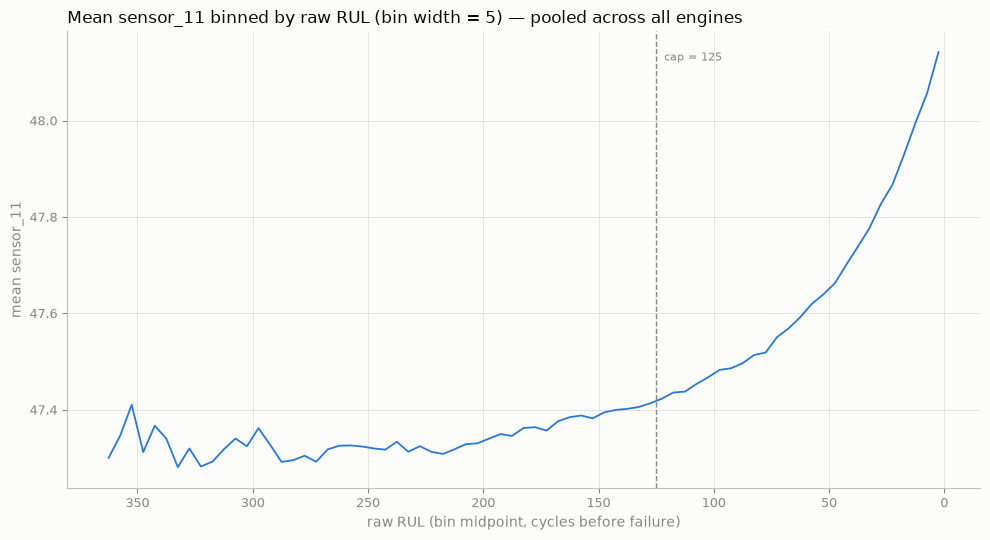

In [10]:
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(binned["bin_mid"], binned["mean"], color=CATEGORICAL_PALETTE[0], linewidth=1.3)
ax.invert_xaxis()  # healthy (high RUL) on the left, failure (0) on the right
ax.axvline(RUL_CAP, color=MUTED, linewidth=1, linestyle="--")
ax.text(
    RUL_CAP, binned["mean"].max(),
    f"  cap = {RUL_CAP}", fontsize=8, color=MUTED, va="top",
)

ax.set_xlabel("raw RUL (bin midpoint, cycles before failure)", fontsize=10, color=MUTED)
ax.set_ylabel(f"mean {JUSTIFY_SENSOR}", fontsize=10, color=MUTED)
ax.set_title(
    f"Mean {JUSTIFY_SENSOR} binned by raw RUL (bin width = {BIN_WIDTH}) — pooled across all engines",
    fontsize=12, color=INK, loc="left",
)
ax.tick_params(colors=MUTED, labelsize=9)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.grid(True, color=GRIDLINE, linewidth=0.6)
ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

In [11]:
# Quantify what the plot shows rather than eyeballing it: within a few raw-RUL bands, how much
# does the binned mean actually move, and how strongly does it correlate with rul_raw?
bands = [(300, 362), (200, 300), (150, 200), (125, 150), (75, 125), (25, 75), (0, 25)]
rows = []
for lo, hi in bands:
    sub = binned[(binned["bin_mid"] >= lo) & (binned["bin_mid"] < hi)]
    rows.append({
        "rul_raw_band": f"[{lo}, {hi})",
        "mean_min": sub["mean"].min(),
        "mean_max": sub["mean"].max(),
        "spread": sub["mean"].max() - sub["mean"].min(),
    })
band_summary = pd.DataFrame(rows)

above_cap = binned[binned["bin_mid"] >= RUL_CAP]
below_cap = binned[binned["bin_mid"] < RUL_CAP]

print(f"std of bin-means, rul_raw >= {RUL_CAP}: {above_cap['mean'].std():.4f}")
print(f"std of bin-means, rul_raw <  {RUL_CAP}: {below_cap['mean'].std():.4f}")
print(f"corr(bin_mid, mean), rul_raw >= {RUL_CAP}: {above_cap['bin_mid'].corr(above_cap['mean']):.3f}")
print(f"corr(bin_mid, mean), rul_raw <  {RUL_CAP}: {below_cap['bin_mid'].corr(below_cap['mean']):.3f}")
band_summary

std of bin-means, rul_raw >= 125: 0.0361
std of bin-means, rul_raw <  125: 0.2100
corr(bin_mid, mean), rul_raw >= 125: -0.594
corr(bin_mid, mean), rul_raw <  125: -0.951


,rul_raw_band,mean_min,mean_max,spread
0,"[300, 362)",47.280667,47.410000,0.129333
1,"[200, 300)",47.291481,47.361500,0.070019
2,"[150, 200)",47.339805,47.387773,0.047968
3,"[125, 150)",47.394325,47.413253,0.018928
4,"[75, 125)",47.422840,47.518660,0.095820
5,"[25, 75)",47.550700,47.826860,0.276160
6,"[0, 25)",47.866740,48.142200,0.275460


**Result.** The transition isn't a sharp elbow sitting exactly at 125 — it's a gradual
acceleration, and being honest about that shape matters more than forcing a clean story. Above
`rul_raw = 125`, the binned mean of `sensor_11` drifts by only ~0.05–0.13 per 75-cycle band
(std of bin-means ≈ 0.036 across the whole region, corr with `rul_raw` ≈ −0.59 —
a weak drift, consistent with noise plus a very slow trend). Below 125, the same statistic jumps
to std ≈ 0.21 (≈6x larger) and corr ≈ −0.95 — a strong, consistent, near-linear
relationship. The steepest part of the curve is actually closer to `rul_raw` < 50–75, not right
at 125, so 125 is a conservative cap: it starts treating the label as "in the degradation phase"
somewhat before the sensor signal is at its most dramatic, but well after the point (≈150–200)
where the flat-noise regime cleanly holds. That's the correct trade-off for a cap — better to
include a bit of genuinely-flat healthy-phase data as "degrading" than to leave part of the real
degradation phase mislabeled as healthy. **125 is a reasonable, empirically-supported cap for
FD001**, not a perfect inflection point but a threshold sitting safely inside the zone where the
regime has already shifted from flat noise to real trend.

## 5. Look at the spread within each bin, not just the mean

The Section 4 plot shows the pooled *mean* of `sensor_11` per RUL bin — but two bins can have
nearly identical means while differing a lot in how tightly the readings cluster around that mean.
`binned` already carries a per-bin `std` from Section 4; add the interquartile range (Q1, Q3) as a
second, outlier-robust spread measure, then plot the mean with the IQR drawn as a shaded band
underneath it. If the band stays wide even where the mean looks flat, the pooled trend is hiding
real per-engine variability rather than describing a tight, shared relationship.

In [12]:
# Q1/Q3 per bin, merged onto the existing mean/std/count frame from Section 4.
quantiles = (
    train_df.groupby(rul_raw_bin, observed=True)[JUSTIFY_SENSOR]
    .quantile([0.25, 0.75])
    .unstack()
    .rename(columns={0.25: "q1", 0.75: "q3"})
    .reset_index(names="rul_raw_bin")
)
quantiles["iqr"] = quantiles["q3"] - quantiles["q1"]

binned = binned.merge(quantiles, on="rul_raw_bin").sort_values("bin_mid").reset_index(drop=True)

binned.head()

,rul_raw_bin,mean,std,count,bin_mid,q1,q3,iqr
0,"[0, 5)",48.14220,0.114281,500,2.5,48.0700,48.22,0.1500
1,"[5, 10)",48.05616,0.114836,500,7.5,47.9800,48.13,0.1500
2,"[10, 15)",47.99516,0.121996,500,12.5,47.9175,48.07,0.1525
3,"[15, 20)",47.92888,0.124092,500,17.5,47.8500,48.01,0.1600
4,"[20, 25)",47.86674,0.137234,500,22.5,47.7700,47.96,0.1900


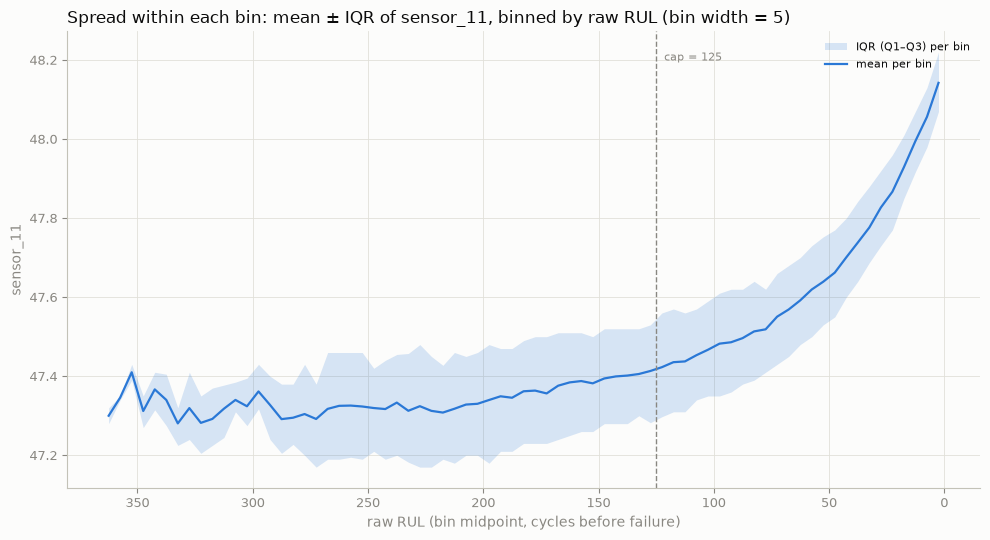

In [13]:
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.fill_between(
    binned["bin_mid"], binned["q1"], binned["q3"],
    color=CATEGORICAL_PALETTE[0], alpha=0.18, linewidth=0, label="IQR (Q1–Q3) per bin",
)
ax.plot(
    binned["bin_mid"], binned["mean"],
    color=CATEGORICAL_PALETTE[0], linewidth=1.6, label="mean per bin",
)

ax.invert_xaxis()  # healthy (high RUL) on the left, failure (0) on the right
ax.axvline(RUL_CAP, color=MUTED, linewidth=1, linestyle="--")
ax.text(
    RUL_CAP, binned["q3"].max(),
    f"  cap = {RUL_CAP}", fontsize=8, color=MUTED, va="top",
)

ax.set_xlabel("raw RUL (bin midpoint, cycles before failure)", fontsize=10, color=MUTED)
ax.set_ylabel(JUSTIFY_SENSOR, fontsize=10, color=MUTED)
ax.set_title(
    f"Spread within each bin: mean ± IQR of {JUSTIFY_SENSOR}, binned by raw RUL (bin width = {BIN_WIDTH})",
    fontsize=12, color=INK, loc="left",
)
ax.tick_params(colors=MUTED, labelsize=9)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.grid(True, color=GRIDLINE, linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(loc="upper right", frameon=False, fontsize=8, labelcolor=INK)

fig.tight_layout()
plt.show()

In [14]:
# Quantify the spread the same way Section 4 quantified the trend: compare typical within-bin
# std and IQR above vs. below the cap.
above_cap = binned[binned["bin_mid"] >= RUL_CAP]
below_cap = binned[binned["bin_mid"] < RUL_CAP]

print(f"mean per-bin std, rul_raw >= {RUL_CAP}: {above_cap['std'].mean():.4f}")
print(f"mean per-bin std, rul_raw <  {RUL_CAP}: {below_cap['std'].mean():.4f}")
print(f"mean per-bin IQR, rul_raw >= {RUL_CAP}: {above_cap['iqr'].mean():.4f}")
print(f"mean per-bin IQR, rul_raw <  {RUL_CAP}: {below_cap['iqr'].mean():.4f}")

mean per-bin std, rul_raw >= 125: 0.1456
mean per-bin std, rul_raw <  125: 0.1510
mean per-bin IQR, rul_raw >= 125: 0.2047
mean per-bin IQR, rul_raw <  125: 0.2161


## 6. Individual engine curves vs. the pooled mean

The pooled mean in Sections 4–5 is averaged over all 100 training engines — it can look smooth
and monotonic even if no single engine's own trajectory resembles it. Sample 12 engines (fixed
seed, reproducible), plot each one's own `sensor_11`-vs-raw-RUL line thin and semi-transparent,
then draw the pooled per-bin mean from Section 4 on top, bold. This checks whether the pooled
trend is representative of individual engines or an artifact of averaging over many noisy ones.

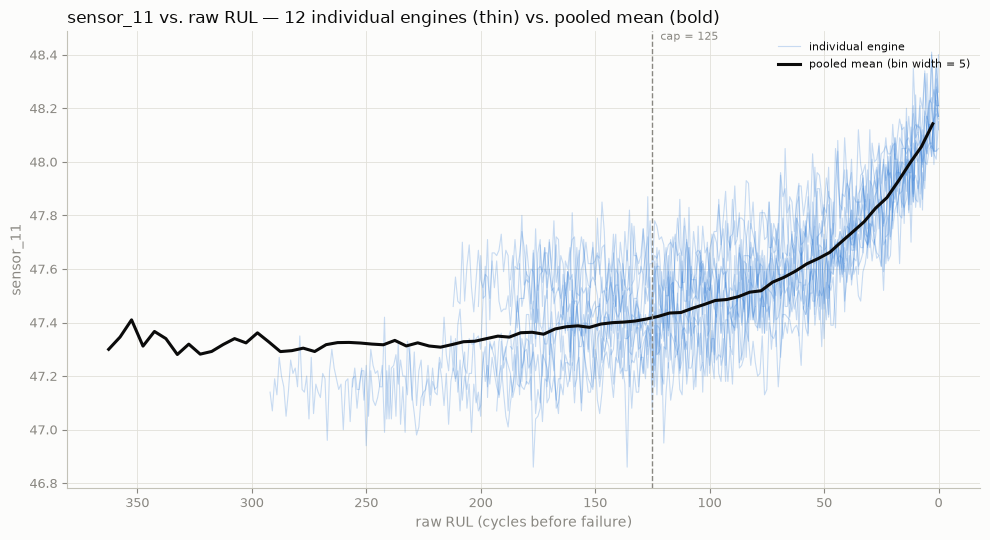

[np.int64(6),
 np.int64(22),
 np.int64(29),
 np.int64(30),
 np.int64(54),
 np.int64(57),
 np.int64(63),
 np.int64(73),
 np.int64(80),
 np.int64(83),
 np.int64(85),
 np.int64(88)]

In [15]:
N_SAMPLE_ENGINES = 12
overlay_rng = np.random.default_rng(7)
sample_engine_ids = sorted(
    overlay_rng.choice(train_df["engine_id"].unique(), size=N_SAMPLE_ENGINES, replace=False)
)

fig, ax = plt.subplots(figsize=(10, 5.5))

for i, engine_id in enumerate(sample_engine_ids):
    eng = train_df[train_df["engine_id"] == engine_id].sort_values("rul_raw")
    ax.plot(
        eng["rul_raw"], eng[JUSTIFY_SENSOR],
        color=CATEGORICAL_PALETTE[0], linewidth=0.8, alpha=0.25,
        label="individual engine" if i == 0 else None,
    )

ax.plot(
    binned["bin_mid"], binned["mean"],
    color=INK, linewidth=2.2, label=f"pooled mean (bin width = {BIN_WIDTH})",
)

ax.invert_xaxis()  # healthy (high RUL) on the left, failure (0) on the right
ax.axvline(RUL_CAP, color=MUTED, linewidth=1, linestyle="--")
ax.text(
    RUL_CAP, ax.get_ylim()[1],
    f"  cap = {RUL_CAP}", fontsize=8, color=MUTED, va="top",
)

ax.set_xlabel("raw RUL (cycles before failure)", fontsize=10, color=MUTED)
ax.set_ylabel(JUSTIFY_SENSOR, fontsize=10, color=MUTED)
ax.set_title(
    f"{JUSTIFY_SENSOR} vs. raw RUL — {N_SAMPLE_ENGINES} individual engines (thin) vs. pooled mean (bold)",
    fontsize=12, color=INK, loc="left",
)
ax.tick_params(colors=MUTED, labelsize=9)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.grid(True, color=GRIDLINE, linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(loc="upper right", frameon=False, fontsize=8, labelcolor=INK)

fig.tight_layout()
plt.show()

sample_engine_ids

## 7. Cross-check other top sensors: sensor_4, sensor_7, sensor_12

Sections 4–6 built the case for the 125 cap using `sensor_11` alone. Do the other sensors Phase 1
ranked highly by pooled correlation with raw RUL — `sensor_4`, `sensor_7`, `sensor_12` — show the
same flat-then-trending shape, or is `sensor_11` a special case? Compute the same pooled per-bin
mean for each, standardize (z-score, using each sensor's own global mean/std) so sensors living on
very different physical scales can share one axis, and overlay all four curves — with the
already-built `sensor_11` curve drawn bold as the reference.

In [16]:
COMPARE_SENSORS = ["sensor_4", "sensor_7", "sensor_11", "sensor_12"]

pooled_means = (
    train_df.groupby(rul_raw_bin, observed=True)[COMPARE_SENSORS]
    .mean()
    .reset_index(names="rul_raw_bin")
)
pooled_means["bin_mid"] = pooled_means["rul_raw_bin"].apply(lambda iv: iv.mid).astype(float)
pooled_means = pooled_means.sort_values("bin_mid").reset_index(drop=True)

# Standardize each sensor by its own global mean/std so curves on very different physical scales
# (e.g. sensor_11 ~ 47-48 vs. other sensors on entirely different units) can share one y-axis.
sensor_stats = train_df[COMPARE_SENSORS].agg(["mean", "std"])
pooled_z = pooled_means[["bin_mid"]].copy()
for sensor in COMPARE_SENSORS:
    pooled_z[sensor] = (
        pooled_means[sensor] - sensor_stats.loc["mean", sensor]
    ) / sensor_stats.loc["std", sensor]

pooled_z.head()

,bin_mid,sensor_4,sensor_7,sensor_11,sensor_12
0,2.5,2.221293,-2.116018,2.250319,-2.175151
1,7.5,1.880740,-1.816456,1.928177,-1.848612
2,12.5,1.617453,-1.594332,1.699788,-1.613782
3,17.5,1.397099,-1.375327,1.451629,-1.407451
4,22.5,1.210241,-1.145972,1.218971,-1.195669


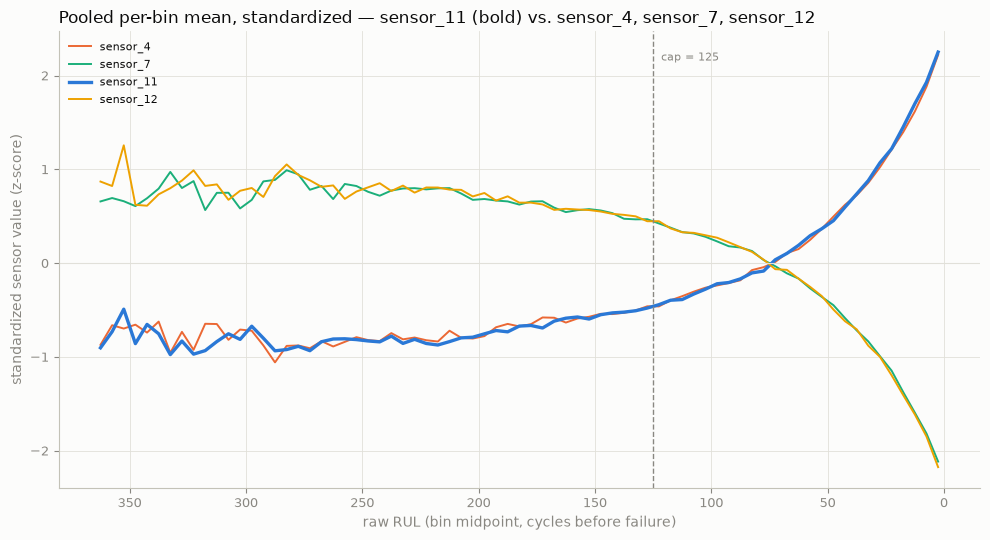

In [17]:
SENSOR_COLORS = {
    "sensor_11": CATEGORICAL_PALETTE[0],
    "sensor_4": CATEGORICAL_PALETTE[1],
    "sensor_7": CATEGORICAL_PALETTE[2],
    "sensor_12": CATEGORICAL_PALETTE[3],
}

fig, ax = plt.subplots(figsize=(10, 5.5))

for sensor in COMPARE_SENSORS:
    ax.plot(
        pooled_z["bin_mid"], pooled_z[sensor],
        color=SENSOR_COLORS[sensor],
        linewidth=2.4 if sensor == "sensor_11" else 1.4,
        label=sensor,
    )

ax.invert_xaxis()  # healthy (high RUL) on the left, failure (0) on the right
ax.axhline(0, color=GRIDLINE, linewidth=0.8)
ax.axvline(RUL_CAP, color=MUTED, linewidth=1, linestyle="--")
ax.text(
    RUL_CAP, pooled_z[COMPARE_SENSORS].to_numpy().max(),
    f"  cap = {RUL_CAP}", fontsize=8, color=MUTED, va="top",
)

ax.set_xlabel("raw RUL (bin midpoint, cycles before failure)", fontsize=10, color=MUTED)
ax.set_ylabel("standardized sensor value (z-score)", fontsize=10, color=MUTED)
ax.set_title(
    "Pooled per-bin mean, standardized — sensor_11 (bold) vs. sensor_4, sensor_7, sensor_12",
    fontsize=12, color=INK, loc="left",
)
ax.tick_params(colors=MUTED, labelsize=9)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.grid(True, color=GRIDLINE, linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(loc="best", frameon=False, fontsize=8, labelcolor=INK)

fig.tight_layout()
plt.show()